## First Steps

the data can be found at `/groups/hephy/mlearning/CaloRegression/training/` and it contains 4 files:

- `test_piplus.hdf5` and `train_piplus.hdf5` contains shower data in which the incident energy was uniformly distributed
- `test_piplus_log.hdf5` and `train_piplus_log.hdf5` contains shower data in which the incident energy was log-uniformly distributed

the names 'train' and 'test' refer to the later use. 

First, we will familiarize ourselves with the dataset. 


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
import argparse
import os
import torch
import torch.nn.functional as F



path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'

In [2]:
# load hdf5, check content and its shape

my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')

for key in my_file:
    print(key)
    print(my_file[key][:].shape)

energy
(70000, 1)
layer_0
(70000, 3, 96)
layer_1
(70000, 12, 12)
layer_2
(70000, 12, 6)
layer_3
(70000, 3, 96)
layer_4
(70000, 12, 12)
layer_5
(70000, 12, 6)
overflow
(70000, 6)


First visualizations (For some inspiration see https://gitlab.com/claudius-krause/caloflow/-/blob/master/plot_calo.py):

- Histogram of $E_{inc}$ (key 'energy' above)
- Histogram of $E_{tot}$ (sum of all deposited energy in all layers)
- Histrograms of $E_i$ (sum of all deposited energy per layer)
- Visualization of a single shower

todo: logscale, density= true

Second: train KDE on layer energies (include $E_{inc}$ as additional dimension), see https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html
todo: 100000 sample size 

Third: set up classifier for evaluation (see https://gitlab.com/claudius-krause/caloflow/-/blob/master/classify.py)

Minimum Incident Energy (E_inc): 1.0001724157455327
Maximum Incident Energy (E_inc): 99.99933068110775


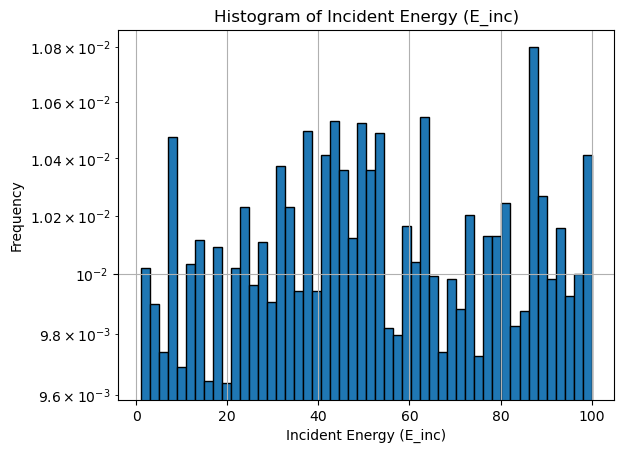

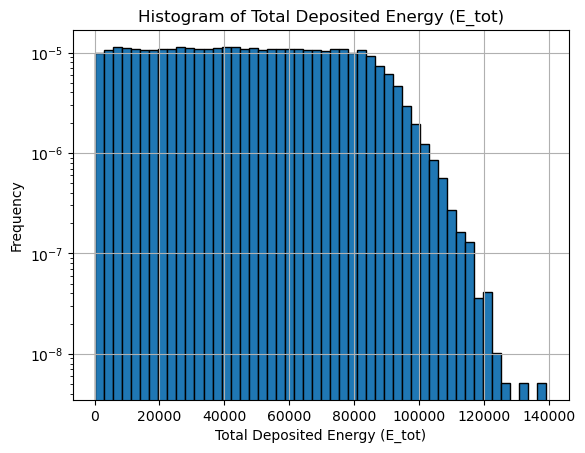

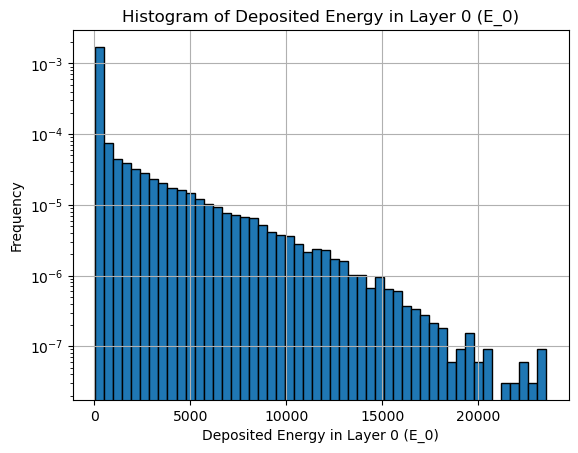

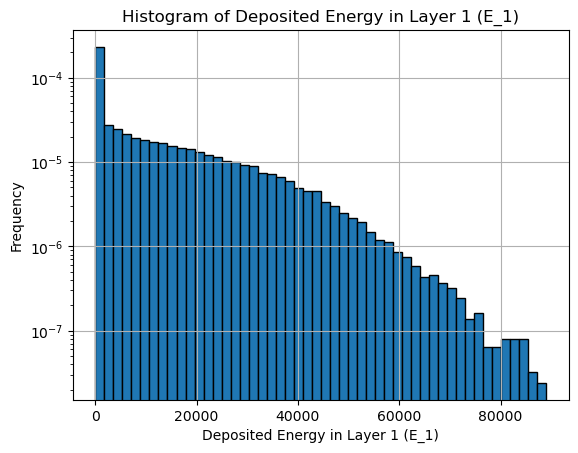

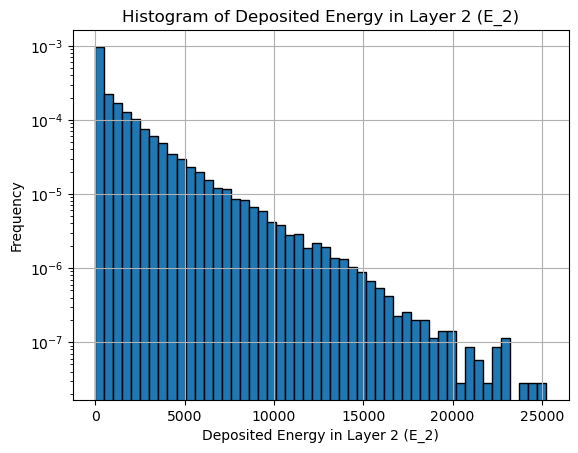

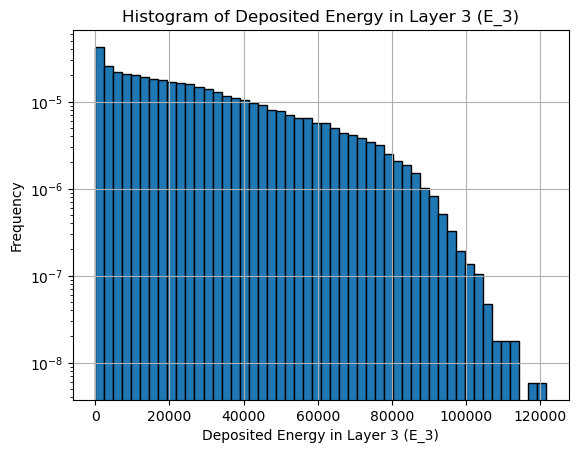

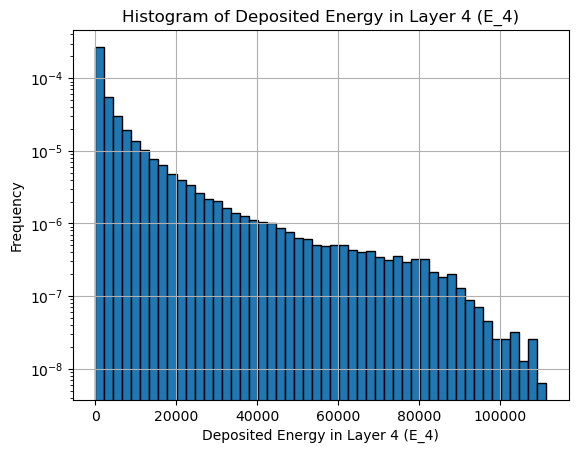

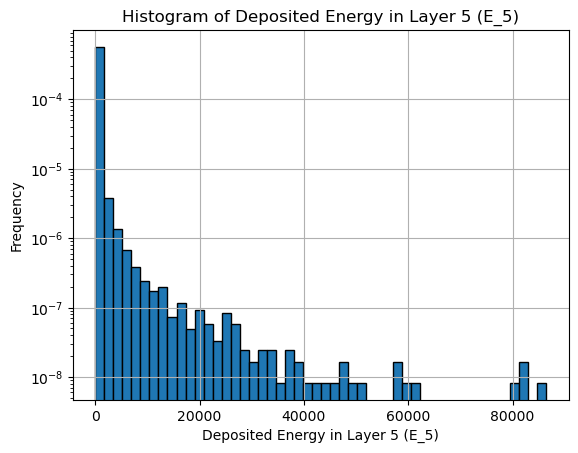

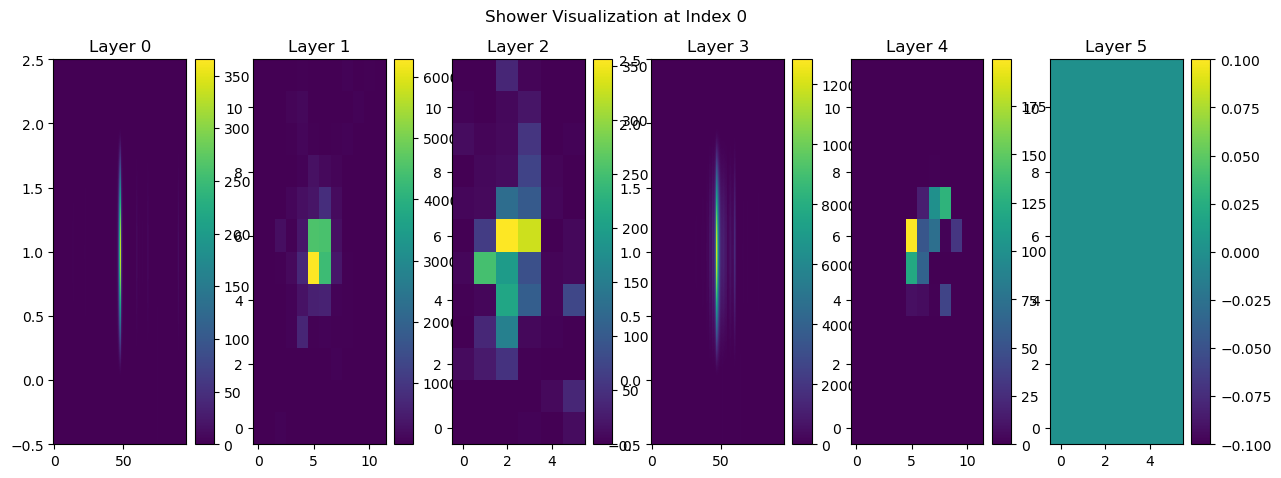

In [3]:
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]

# Print minimum and maximum energy
min_energy = energy.min()
max_energy = energy.max()
print(f"Minimum Incident Energy (E_inc): {min_energy}")
print(f"Maximum Incident Energy (E_inc): {max_energy}")

plt.figure()
plt.hist(energy, bins=50, edgecolor='k', density=True, log=True)
plt.xlabel('Incident Energy (E_inc)')
plt.ylabel('Frequency')
plt.title('Histogram of Incident Energy (E_inc)')
plt.grid(True)
plt.show()

# 2. Histogram of E_tot (sum of all deposited energy in all layers)
E_tot = np.sum([layer.sum(axis=(1, 2)) for layer in layers], axis=0)
plt.figure()
plt.hist(E_tot, bins=50, edgecolor='k', density=True, log=True)
plt.xlabel('Total Deposited Energy (E_tot)')
plt.ylabel('Frequency')
plt.title('Histogram of Total Deposited Energy (E_tot)')
plt.grid(True)
plt.show()

# 3. Histograms of E_i (sum of all deposited energy per layer)
for i, layer in enumerate(layers):
    E_i = layer.sum(axis=(1, 2))
    plt.figure()
    plt.hist(E_i, bins=50, edgecolor='k', density=True, log=True)
    plt.xlabel(f'Deposited Energy in Layer {i} (E_{i})')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Deposited Energy in Layer {i} (E_{i})')
    plt.grid(True)
    plt.show()

# 4. Visualization of a single shower
shower_index = 0
plt.figure(figsize=(15, 5))
for i, layer in enumerate(layers):
    plt.subplot(1, 6, i+1)
    plt.imshow(layer[shower_index], aspect='auto', origin='lower')
    plt.colorbar()
    plt.title(f'Layer {i}')
plt.suptitle(f'Shower Visualization at Index {shower_index}')
plt.show()

Final samples shape: (100000, 7)
Generated 100000 valid samples.


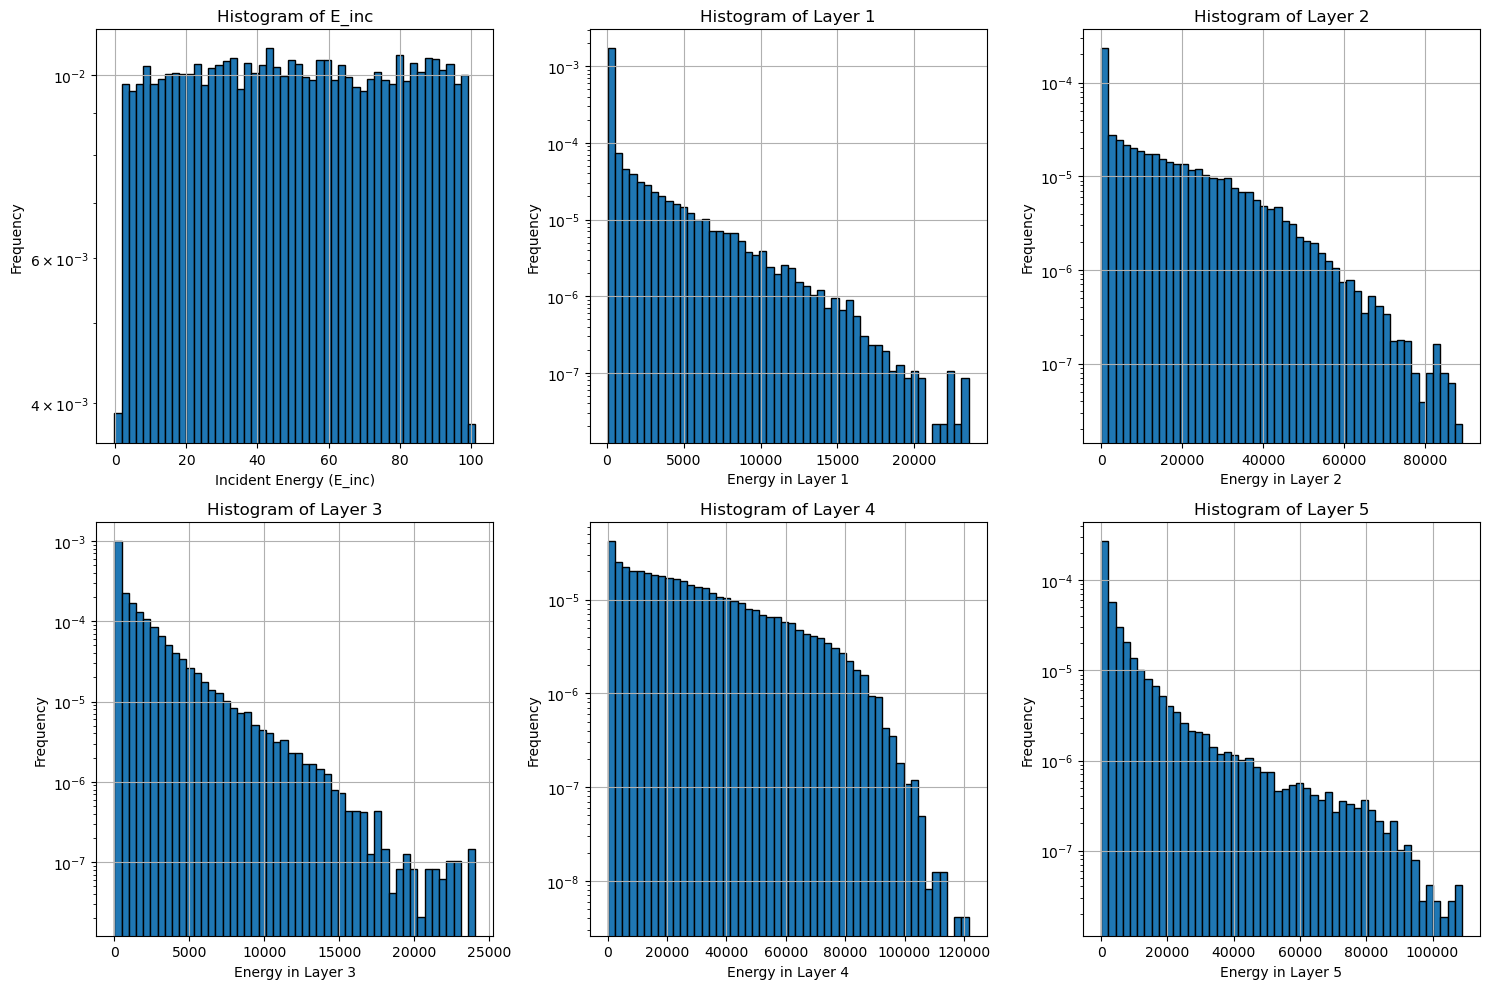

In [4]:
#TASK 2:
# deposited energy per layer
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T

# incident energy and layer energies in one dataset
#FIXED
#data = np.hstack((energy, E_layers))
data = np.hstack((energy.reshape(-1,1), E_layers))

# train KDE
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(data)

# example of sampling
samples = kde.sample(n_samples=100000)

print(f"Final samples shape: {samples.shape}")
print(f"Generated {len(samples)} valid samples.")

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

for i in range(6):
    axs[i].hist(samples[:, i], bins=50, edgecolor='k',density=True, log=True)
    axs[i].set_xlabel(f'Energy in Layer {i}' if i > 0 else 'Incident Energy (E_inc)')
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Histogram of {"Layer " + str(i) if i > 0 else "E_inc"}')
    axs[i].grid(True)

plt.tight_layout()
plt.show()

In [5]:
#TASK 3
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import copy

#KDE SETUP
#data setup
path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]

# incident and layer energies in one dataset
E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T
energy_reshaped = energy.reshape(-1, 1)
data = np.hstack((energy_reshaped, E_layers))

#train KDE
kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(data)

# generate KDE samples
n_samples = len(data)
kde_samples = kde.sample(n_samples)

# Create labels
real_labels = np.ones(n_samples)
kde_labels = np.zeros(n_samples)

# combining of real and KDE gen data
combined_data = np.vstack((data, kde_samples))
combined_labels = np.hstack((real_labels, kde_labels))

# split into trainning and test sets
X_train, X_test, y_train, y_test = train_test_split(combined_data, combined_labels, test_size=0.2, random_state=42)

#CLASSIFIER SETUP
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc3(x))
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    preds = torch.round(outputs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('highest validation accuracy: {:4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model

def evaluate_model(model, dataloaders):
    model.eval()
    all_preds = []
    all_labels = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            preds = torch.round(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_preds)
    print('Accuracy: {:.4f}, AUC (area under roc curve): {:.4f}'.format(acc, auc))
    return acc, auc

# dataloader setup
train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)
}

# Model, criterion, optimizer
input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# train & evaluate
model = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
evaluate_model(model, dataloaders)

Epoch number 0/24
----------
train Loss: 49.9990 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 1/24
----------
train Loss: 50.0832 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 2/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 3/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 4/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 5/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 6/24
----------
train Loss: 50.0857 Acc: 0.4991
val Loss: 49.6607 Acc: 0.5034
Epoch number 7/24
----------
train Loss: 50.0705 Acc: 0.4993
val Loss: 49.6607 Acc: 0.5034
Epoch number 8/24
----------
train Loss: 50.0839 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 9/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.5034
Epoch number 10/24
----------
train Loss: 50.0848 Acc: 0.4992
val Loss: 49.6607 Acc: 0.503

(0.5033928571428572, 0.5)


=== E_true = 10 GeV | events used: 5000 | scan points: 200 ===
  regression progress: 250/5000 events (5.0%), rate=8.2 ev/s, ETA=9.7 min
  regression progress: 500/5000 events (10.0%), rate=8.5 ev/s, ETA=8.8 min
  regression progress: 750/5000 events (15.0%), rate=8.7 ev/s, ETA=8.2 min
  regression progress: 1000/5000 events (20.0%), rate=8.8 ev/s, ETA=7.6 min
  regression progress: 1250/5000 events (25.0%), rate=9.1 ev/s, ETA=6.9 min
  regression progress: 1500/5000 events (30.0%), rate=9.2 ev/s, ETA=6.3 min
  regression progress: 1750/5000 events (35.0%), rate=9.1 ev/s, ETA=6.0 min
  regression progress: 2000/5000 events (40.0%), rate=9.3 ev/s, ETA=5.4 min
  regression progress: 2250/5000 events (45.0%), rate=9.2 ev/s, ETA=5.0 min
  regression progress: 2500/5000 events (50.0%), rate=9.2 ev/s, ETA=4.5 min
  regression progress: 2750/5000 events (55.0%), rate=9.3 ev/s, ETA=4.0 min
  regression progress: 3000/5000 events (60.0%), rate=9.3 ev/s, ETA=3.6 min
  regression progress: 3250/

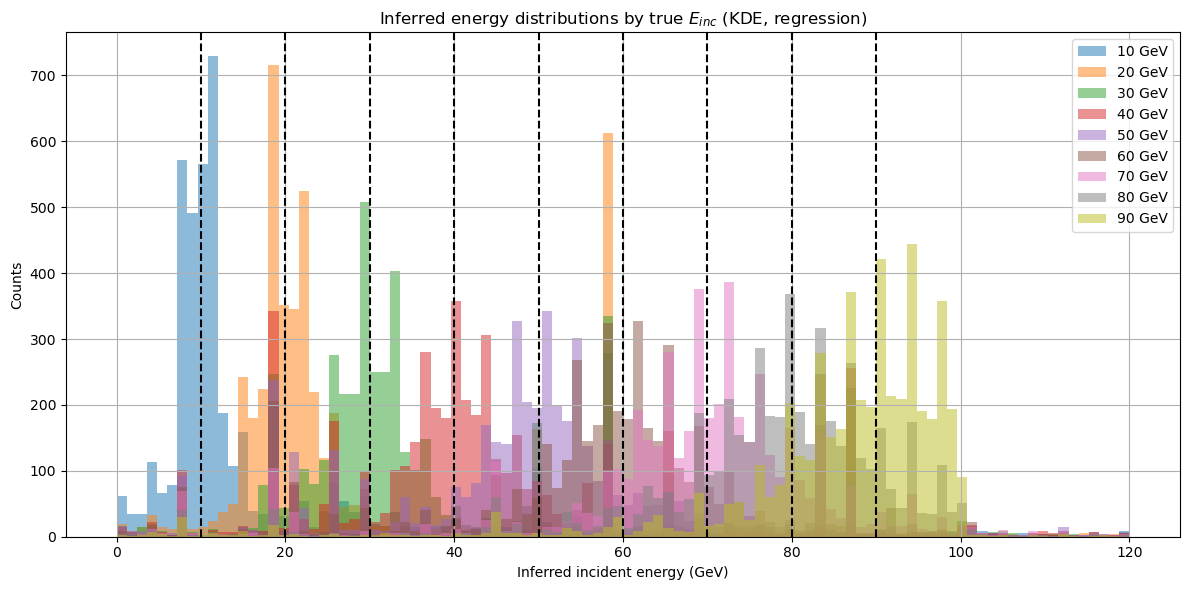

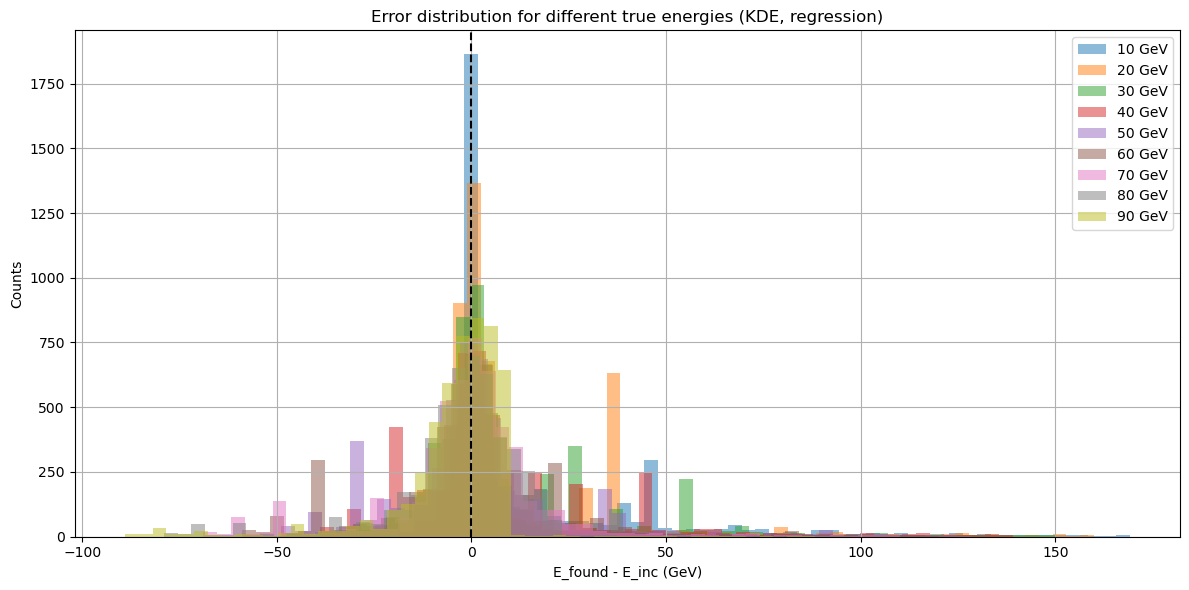


Regression time: 1h 26m 13.50s


In [6]:
# =========================
# KDE REGRESSION / ENERGY INFERENCE (FAST + PROGRESS + SAFE)
# =========================

import time
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt

reg_start_time = time.time()

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))  # 10, 20, ..., 90
errors_by_energy = {}

# --- SPEED FIXES (set here) ---
NUM_SCAN_POINTS = 200     # was 1000 (5x faster)
MAX_EVENTS_PER_FILE = 5000  # was all events (often ~100k) (20x faster)
E_MIN = 1.0
E_MAX = 180.0

def load_eval_layers(filepath, max_events=None):
    with h5py.File(filepath, 'r') as f:
        layers_eval = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers_eval = np.array([layer.sum(axis=(1, 2)) for layer in layers_eval]).T

    E_layers_eval = np.clip(E_layers_eval, a_min=0.0, a_max=None)

    if max_events is not None and len(E_layers_eval) > max_events:
        # deterministic subsample (first max_events)
        E_layers_eval = E_layers_eval[:max_events]

    return E_layers_eval

def infer_incident_energy_kde(
    kde_model,
    layer_matrix,
    num_scan_points=NUM_SCAN_POINTS,
    E_min=E_MIN,
    E_max=E_MAX,
    batch_events=250,           # event batching to avoid huge RAM
    batch_scan=200,             # scan batching
    progress_every=1            # print per event-batch
):
    """
    KDE regression by likelihood scan:
      E_pred(x) = argmax_E log p_kde([E, layers])

    Batching is critical: avoids allocating (N * M * 7) huge arrays.
    """
    n = layer_matrix.shape[0]
    E_candidates = np.linspace(E_min, E_max, num_scan_points).reshape(-1, 1)  # (M,1)

    inferred_E = np.empty(n, dtype=np.float64)

    t0 = time.time()
    for start in range(0, n, batch_events):
        end = min(start + batch_events, n)
        X_layers = layer_matrix[start:end]  # (B,6)
        B = X_layers.shape[0]

        # we will find argmax over E for each event in this batch
        best_logp = np.full(B, -np.inf, dtype=np.float64)
        best_E = np.full(B, E_candidates[0, 0], dtype=np.float64)

        # scan E in chunks
        for s0 in range(0, num_scan_points, batch_scan):
            s1 = min(s0 + batch_scan, num_scan_points)
            E_chunk = E_candidates[s0:s1]  # (S,1)
            S = E_chunk.shape[0]

            # build candidates without huge 3D arrays:
            # flat shape: (B*S, 7) = [E, layer0..layer5]
            E_rep = np.repeat(E_chunk, B, axis=0)          # (B*S,1)
            L_rep = np.tile(X_layers, (S, 1))              # (B*S,6)
            flat = np.hstack([E_rep, L_rep])               # (B*S,7)

            # IMPORTANT: KDE was fit on raw data -> evaluate on raw candidates (no log1p)
            logp_flat = kde_model.score_samples(flat)      # (B*S,)

            # reshape to (S,B) to max over scan for each event
            logp_SB = logp_flat.reshape(S, B)
            chunk_best = logp_SB.max(axis=0)               # (B,)
            chunk_arg = logp_SB.argmax(axis=0)             # (B,)
            chunk_E = E_chunk[chunk_arg, 0]                # (B,)

            # update best
            improve = chunk_best > best_logp
            best_logp[improve] = chunk_best[improve]
            best_E[improve] = chunk_E[improve]

        inferred_E[start:end] = best_E

        if progress_every and ((start // batch_events) % progress_every == 0):
            dt = time.time() - t0
            done = end
            rate = done / dt if dt > 0 else 0.0
            remaining = n - done
            eta = remaining / rate if rate > 0 else float('inf')
            print(
                f"  regression progress: {done}/{n} events "
                f"({100.0*done/n:.1f}%), "
                f"rate={rate:.1f} ev/s, "
                f"ETA={eta/60:.1f} min"
            )

    return inferred_E

# =========================
# RUN REGRESSION
# =========================
for E_true in energy_values:
    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')

    layer_tensor = load_eval_layers(file_path, max_events=MAX_EVENTS_PER_FILE)
    print(f"\n=== E_true = {E_true} GeV | events used: {len(layer_tensor)} | scan points: {NUM_SCAN_POINTS} ===")

    inferred = infer_incident_energy_kde(kde, layer_tensor)

    error = inferred - E_true
    errors_by_energy[E_true] = error

    print(
        f"E_inc={E_true} GeV: "
        f"mean error = {np.mean(error):.2f}, "
        f"std = {np.std(error):.2f}"
    )

    # Histogram + metrics
    bins = 100
    counts, bin_edges = np.histogram(inferred, bins=bins, range=(1, 180))

    bin_idx = np.digitize(E_true, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, len(counts) - 1)

    ratio_true_bin = counts[bin_idx] / counts.sum() if counts.sum() > 0 else 0.0
    print(f"  True-bin ratio: {ratio_true_bin:.2%}")

    half_max = counts.max() / 2
    above = np.where(counts >= half_max)[0]
    if len(above) > 0:
        fwhm = bin_edges[above[-1] + 1] - bin_edges[above[0]]
    else:
        fwhm = 0.0

    print(f"  FWHM: {fwhm:.2f} GeV")

# =========================
# PLOT 1: Inferred energies (bunt)
# =========================
plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(
        error + E_true,
        bins=100,
        range=(0, 120),
        alpha=0.5,
        label=f'{E_true} GeV'
    )
    plt.axvline(E_true, color='black', linestyle='--')

plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (KDE, regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# PLOT 2: Error distributions (bunt)
# =========================
plt.figure(figsize=(12, 6))
for E_true, error in errors_by_energy.items():
    plt.hist(error, bins=50, alpha=0.5, label=f'{E_true} GeV')

plt.axvline(0, color='black', linestyle='--')
plt.xlabel("E_found - E_inc (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution for different true energies (KDE, regression)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# REGRESSION TIME
# =========================
reg_end_time = time.time()
elapsed = reg_end_time - reg_start_time
h, rem = divmod(elapsed, 3600)
m, s = divmod(rem, 60)
print(f"\nRegression time: {int(h)}h {int(m)}m {s:.2f}s")
